In [8]:
# setting the environment variables, the keys
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

from config import set_environment

# for the keys - as explained early in chapter 2
set_environment()

In [17]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [19]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

prompt = PromptTemplate.from_template("Answer the following question: {question}")
custom_chain = prompt | llm | StrOutputParser()
custom_chain.invoke("what colour is the moon?")

'The Moon\'s color is not fixed and can appear to be various shades depending on several factors, primarily the Earth\'s atmosphere and the time of observation.\n\nHere\'s a breakdown:\n\n1.  **Default/Intrinsic Color (White/Grey/Silvery):**\n    *   Generally, the Moon appears to be a shade of **white, grey, or silvery-white**.\n    *   This is because its surface is made of dark grey rocky material (volcanic basalt and lighter anorthosite) and it reflects sunlight. Sunlight itself is "white" (containing all colors).\n\n2.  **Yellow/Orange/Red (Atmospheric Effects):**\n    *   When the Moon is **low on the horizon**, or when there\'s a lot of **dust, smoke, or pollution** in the atmosphere, it can appear **yellow, orange, or even red**.\n    *   This happens because the Earth\'s atmosphere scatters away shorter wavelength blue light, allowing longer wavelength red and orange light to reach our eyes more easily. This is the same reason sunsets and sunrises appear red or orange.\n    * 

# Built-in tools

An example of using a search engine as a tool. Let's create one based on DuckDuckGo search and explore its name, description and arguments' schema:

In [57]:
from langchain_community.tools import DuckDuckGoSearchRun

search = DuckDuckGoSearchRun(api_wrapper_kwargs={"backend": "api"})

print(f"Tool's name = {search.name}")
print(f"Tool's description = {search.description}")
print(f"Tool's arg schema = {search.args_schema}")

Tool's name = duckduckgo_search
Tool's description = A wrapper around DuckDuckGo Search. Useful for when you need to answer questions about current events. Input should be a search query.
Tool's arg schema = <class 'langchain_community.tools.ddg_search.tool.DDGInput'>


In [27]:
from langchain_community.tools.ddg_search.tool import DDGInput

print(DDGInput.model_fields)

{'query': FieldInfo(annotation=str, required=True, description='search query to look up')}


Let's run the tool:

In [29]:
query = "What is the weather in Munich like tomorrow?"
search_input = DDGInput(query=query)
result = search.invoke(search_input.model_dump())
print(result)

What's the weather like in Munich ? Weather in Munich right now: overcast, air temperature +2°, feels like 0°. Wind speed and direction is 1 m/s, N, humidity is 100%, atmospheric pressure is 717 mmHg. Munich , Bavaria. 11°C. Location. Munich Weather Radar. Static Radar Temporarily Unavailable. Thank you for your patience as we work to get everything up and running again. Experiencing the weather in Munich is akin to enjoying a landscape that transforms with each season. Renowned for its rich history and vibrant culture, Munich , the capital of Bavaria, also offers a distinctive climate that enhances its charm. Munich - Weather warnings issued. 14-day forecast.Outlook forecast map. Munich . 22:00 Wednesday. Full screen. The weather data for Munich for tomorrow and the following three days is obtained from the NOAA GFS FV3 model. Short-range numerical forecasts, covering today, tomorrow , and the next three days, offer the highest accuracy compared to long-term forecasts.


Now let's enhance an LLM with this tool:

In [30]:
from langchain_core.messages import SystemMessage, HumanMessage

result = llm.invoke([
    SystemMessage(content="Always use a duckduckgo search tool for queries that require a fresh information"),
    HumanMessage(content=query)
    ],
    tools=[search]
)

In [31]:
print(result.tool_calls[0])

{'name': 'duckduckgo_search', 'args': {'query': 'weather in Munich tomorrow'}, 'id': '2c4b8f9d-733e-4edd-b0cd-ea939c7d1ea7', 'type': 'tool_call'}


And we can double-check that the model invokes a search tool only when needed:

In [37]:
messages = [
    SystemMessage(
        "Always use a duckduckgo_search tool for queries that require a fresh information"
    ),
    HumanMessage(
        "How much is 2+2?"
    )
]

result = llm.invoke(messages, tools=[search])
print(result)
print(result.tool_calls)
assert not result.tool_calls

content='4' additional_kwargs={} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []} id='run--ec500944-0b12-44d7-9e3a-085e6f825dff-0' usage_metadata={'input_tokens': 90, 'output_tokens': 1, 'total_tokens': 91, 'input_token_details': {'cache_read': 0}}
[]


And we can create a ReACT agent that uses this tool, and explore its workflow graph:

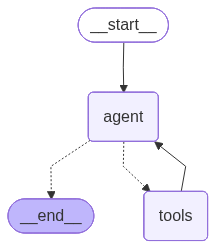

In [42]:
from langgraph.prebuilt import create_react_agent
from IPython.display import Image, display

agent = create_react_agent(
  model=llm,
  tools=[search],
  prompt="Always use a duckduckgo_search tool for queries that require a fresh information"
)

display(Image(agent.get_graph().draw_mermaid_png()))

If we run it, we can see the tool calls appearing during execution:

In [45]:
for event in agent.stream({"messages": [HumanMessage("Whats the whether like tomorrow in munich?")]}):
    messages = event.get("agent", event.get("tools", {})).get("messages", [])
    for m in messages:
        m.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (ee32c342-abb3-4072-b28f-d3c4c09cdf74)
 Call ID: ee32c342-abb3-4072-b28f-d3c4c09cdf74
  Args:
    query: weather tomorrow Munich
================================= Tool Message =================================
Name: duckduckgo_search

Get the latest hourly weather updates for Munich tomorrow . Detailed forecast including temperature, wind, rain, snow, and UV index. Stay informed about tomorrow's weather conditions in Munich . Latest weather forecast for Munich for tomorrow's , hourly weather forecast, including tomorrow's temperatures in Munich , wind, rain and more. Munich 7 day weather forecast including weather warnings, temperature, rain, wind, visibility, humidity and UV Detailed weather forecast ⚡ in Munich , Bavaria today, tomorrow and 7 days. Wind, precipitation, 🌡️ air temperature, clouds and atmospheric pressure - World- Weather .info Get the detailed weather forec

We can also create a tool ourselves from other building blocks:

In [76]:
from langchain_core.tools import Tool
from langchain_experimental.utilities import PythonREPL

python_repl = PythonREPL()
python_repl.run("print(2**4)")

code_interpreter_tool = Tool(
    name="python_repl",
    description="A Python shell. Use this to execute python commands. Inputs should be a valid python command. If you want to see the output of a value, you should print it out with `print(...)`",
    func=python_repl.run,
)

In [78]:
code_interpreter_tool.invoke("print([item for item in [1, 2, 3]])")

'[1, 2, 3]\n'

This is a famous failure of an LLM:

In [73]:
llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash-001", temperature=2.0)

In [74]:
query_strawberry = "How many r are in the word strawberry?"
print(llm.invoke(query_strawberry).content)

There are 4 "r"s in the word "strawberry".


In [75]:
query_strawberry = "How many r are in the word strawberry?"
print(llm.invoke(query_strawberry).content)

There are three "r"s in the word "strawberry".


But we can see that ReACT agent easily solved this problem by invoking an external tool:

In [81]:
agent = create_react_agent(
    model=llm,
    tools=[code_interpreter_tool]
)

for event in agent.stream({"messages": [HumanMessage(query_strawberry)]}):
    messages = event.get("agent", event.get("tools", {})).get("messages", [])
    for m in messages:
        m.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  python_repl (d5ae678f-a456-4c71-9fca-32b2b14d0e76)
 Call ID: d5ae678f-a456-4c71-9fca-32b2b14d0e76
  Args:
    __arg1: print("strawberry".count("r"))
================================= Tool Message =================================
Name: python_repl

3

================================== Ai Message ==================================

There are 3 r's in the word strawberry.


We can also use any third-pary API by wrapping it a tool. But first, we need to define a schema (below is an example for an open-sourced [exchange rates API](https://api.frankfurter.dev/v1)):

In [82]:
api_spec = """
openapi: 3.0.0
info:
  title: Frankfurter Currency Exchange API
  version: v1
  description: API for retrieving currency exchange rates. Pay attention to the base currency and change it if needed.

servers:
  - url: https://api.frankfurter.dev/v1

paths:
  /v1/{date}:
    get:
      summary: Get exchange rates for a specific date.
      parameters:
        - in: path
          name: date
          schema:
            type: string
            pattern: '^\d{4}-\d{2}-\d{2}$' # YYYY-MM-DD format
          required: true
          description: The date for which to retrieve exchange rates.  Use YYYY-MM-DD format.  Example: 2009-01-04
        - in: query
          name: symbols
          schema:
            type: string
          description: Comma-separated list of currency symbols to retrieve rates for. Example: GBP,USD,EUR

  /v1/latest:
    get:
      summary: Get the latest exchange rates.
      parameters:
        - in: query
          name: symbols
          schema:
            type: string
          description: Comma-separated list of currency symbols to retrieve rates for. Example: CHF,GBP
        - in: query
          name: base
          schema:
            type: string
          description: The base currency for the exchange rates. If not provided, EUR is used as a base currency. Example: USD
"""

We can wrap it with an out-of-the-box `TextRequestsWrapper`:

In [83]:
from langchain_community.agent_toolkits.openapi.toolkit import RequestsToolkit
from langchain_community.utilities.requests import TextRequestsWrapper

toolkit = RequestsToolkit(
    requests_wrapper=TextRequestsWrapper(headers={}),
    allow_dangerous_requests=True
)

for tool in toolkit.get_tools():
    print(tool.name)

requests_get
requests_post
requests_patch
requests_put
requests_delete


Our ReACT agent now looks like this (note, that we have modified the system message):

In [104]:
system_message = SystemMessage(
    f"You're given the API spec:\n{api_spec}\n"
    "Use the API to answer users' queries if possible. "
)

agent = create_react_agent(
    llm,
    toolkit.get_tools(),
    prompt=system_message,
)

query = "What is the swiss franc to US dollar exchange rate?"

events = agent.stream(
    {"messages": [HumanMessage(query)]},
    stream_mode="values",
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

What is the swiss franc to US dollar exchange rate?
================================== Ai Message ==================================
Tool Calls:
  requests_get (04e96bde-a7b4-4e18-9eaf-e5ba7794c2e6)
 Call ID: 04e96bde-a7b4-4e18-9eaf-e5ba7794c2e6
  Args:
    url: https://api.frankfurter.dev/v1/latest?symbols=USD&base=CHF
================================= Tool Message =================================
Name: requests_get

{"amount":1.0,"base":"CHF","date":"2025-12-23","rates":{"USD":1.2691}}
================================== Ai Message ==================================

The Swiss Franc to US Dollar exchange rate is 1 CHF = 1.2691 USD.
